# Experimental designs: space-filling and optimal

How to choose a fixed batch of input points up front - before you have any data - when you can't sample sequentially. Two families in `mixle.doe`: space-filling designs (random, Latin hypercube, maximin, and the low-discrepancy Sobol/Halton sequences) that cover the space evenly with no model, and optimal designs (D/A/I-optimal) that, given a model, place points to minimize parameter or prediction variance.


## Designs, the information matrix, and optimality criteria

Fix a regression model $y = f(x)^\top\beta + \varepsilon$ with $\varepsilon\sim\mathcal N(0,\sigma^2)$ and
a design, a choice of input points $x_1,\dots,x_n$. Stacking the model vectors into the design matrix
$X$ (row $i$ is $f(x_i)^\top$), the least-squares estimator has covariance
$\mathrm{Cov}(\hat\beta)=\sigma^2 (X^\top X)^{-1}$. The (per-observation) information matrix is
$M=\tfrac1n X^\top X$. Choosing the design well means making $M$ large in a precise sense, and the
standard scalar summaries of "large" are the alphabetic optimality criteria.

Definition (optimality criteria).
- D-optimality maximizes $\det M$, equivalently minimizes the volume of the joint confidence ellipsoid
  for $\beta$.
- A-optimality minimizes $\operatorname{tr} M^{-1}$, the average coefficient variance.
- E-optimality maximizes the smallest eigenvalue of $M$, the worst-case coefficient variance.
- I-optimality (also V) minimizes the average prediction variance over the design region.
- G-optimality minimizes the maximum prediction variance over the region.

Each criterion answers a different question: D for parameter precision overall, A for average precision,
G and I for prediction. They generally pick different designs, so the criterion must match the goal.

## The equivalence theorem and space-filling designs

Theorem (Kiefer-Wolfowitz general equivalence). For an approximate (measure) design, D-optimality and
G-optimality are equivalent, and at the optimum the maximum prediction variance equals $p$, the number of
parameters. The standardized prediction variance $d(x)=f(x)^\top M^{-1} f(x)$ satisfies
$\max_x d(x)=p$ exactly at a D-optimal design.

Proof idea. The D-criterion $\log\det M$ is concave in the design measure; its directional derivative
toward a one-point design at $x$ is $d(x)-p$. A measure is D-optimal iff this derivative is nonpositive
everywhere, i.e. $d(x)\le p$ for all $x$, with equality on the support. Since $\int d(x)\,d\xi = p$ always,
this forces $\max_x d(x)=p$, which is exactly G-optimality. $\quad\blacksquare$

When no model is fixed in advance, the goal flips from parameter precision to covering the input space
uniformly. Space-filling designs (Latin hypercube, maximin, low-discrepancy Sobol and Halton sequences)
spread points to minimize gaps.

Theorem (Koksma-Hlawka). For integrating a function $g$ of bounded variation $V(g)$ using points with
star-discrepancy $D_n^\star$,
$$\Big|\tfrac1n\sum_i g(x_i) - \int g\Big| \le V(g)\,D_n^\star.$$
Low-discrepancy sequences achieve $D_n^\star = O((\log n)^d/n)$, far better than the $O(n^{-1/2})$ of
random points, which is why quasi-Monte Carlo designs integrate and explore more efficiently.

Counterexample (criteria are model-dependent). A D-optimal design for a first-order model places all
points at the extremes of the region and cannot even detect curvature; if the true model is quadratic it
is badly biased. Space-filling designs are model-robust but, as the D-efficiency computation in this
notebook shows, pay an efficiency price when the model is in fact known. There is no single best design,
only a best design for a stated model and goal.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.doe import (random_design, latin_hypercube, maximin_latin_hypercube, sobol_design,
                      halton_design, optimal_design, polynomial_features)
rng = np.random.RandomState(0)
bounds = [(0.0, 1.0), (0.0, 1.0)]

## 1. Space-filling designs

With no data and no model, the goal is to cover the input space evenly so nothing is under-sampled. Random points clump and leave holes. Latin hypercube guarantees uniform 1-D projections; maximin LHS also maximizes the minimum pairwise distance; Sobol and Halton are low-discrepancy sequences engineered for even high-dimensional coverage (and they extend incrementally). We compare them by the maximin metric - the minimum pairwise distance, larger is better-spread.


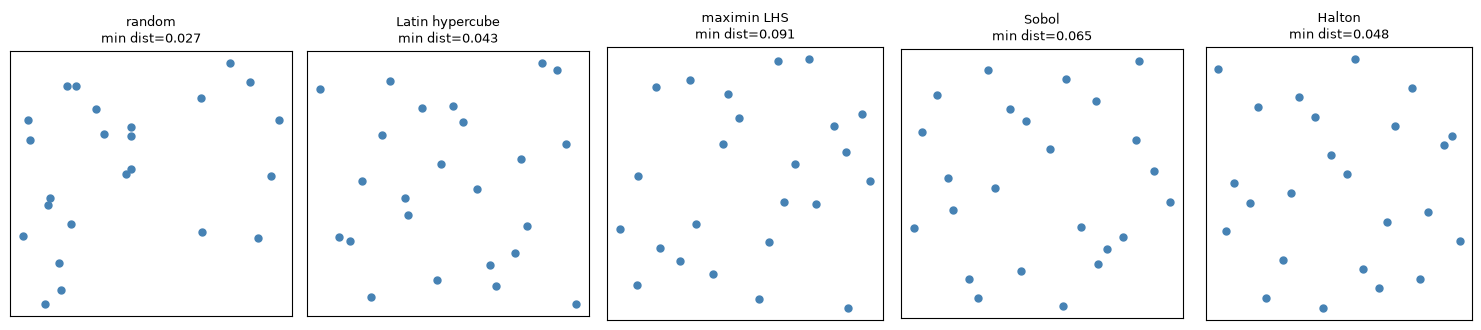

larger min-distance = better space-filling: {'random': 0.027, 'Latin hypercube': 0.043, 'maximin LHS': 0.091, 'Sobol': 0.065, 'Halton': 0.048}


In [2]:
designs = {'random': random_design(bounds, 24, seed=1),
           'Latin hypercube': latin_hypercube(bounds, 24, seed=1),
           'maximin LHS': maximin_latin_hypercube(bounds, 24, seed=1, trials=64),
           'Sobol': sobol_design(bounds, 24, seed=1),
           'Halton': halton_design(bounds, 24)}
def min_dist(d):
    from scipy.spatial.distance import pdist
    return float(pdist(d).min())
fig, ax = plt.subplots(1, 5, figsize=(15, 3.2))
for a, (name, d) in zip(ax, designs.items()):
    a.scatter(d[:, 0], d[:, 1], s=25, color='steelblue'); a.set_aspect('equal')
    a.set_title('%s\nmin dist=%.3f' % (name, min_dist(d)), fontsize=9); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()
print('larger min-distance = better space-filling:',
      {k: round(min_dist(v), 3) for k, v in designs.items()})

## 2. Optimal designs: let the model choose the points

When you do have a model - say you intend to fit a quadratic regression - you can do better than space-filling: place points to minimize the variance of the fit. An optimal design maximizes a functional of the information matrix $M=F^\top F$ (where $F$ is the model's feature matrix):

- D-optimal maximizes $\det M$ - smallest joint confidence ellipsoid on the coefficients;
- A-optimal minimizes $\mathrm{tr}\,M^{-1}$ - smallest average coefficient variance;
- I-optimal minimizes average prediction variance over the region.

`optimal_design` runs a Fedorov exchange over a candidate pool for a given `model` and `criterion`. For a quadratic model the D-optimal points pile up at the corners/edges/center - exactly where a curved surface is pinned down. We compare its D-efficiency to a random design.


D-criterion  log|FᵀF|   D-optimal: -1.84   random: -7.00  (higher = more information)


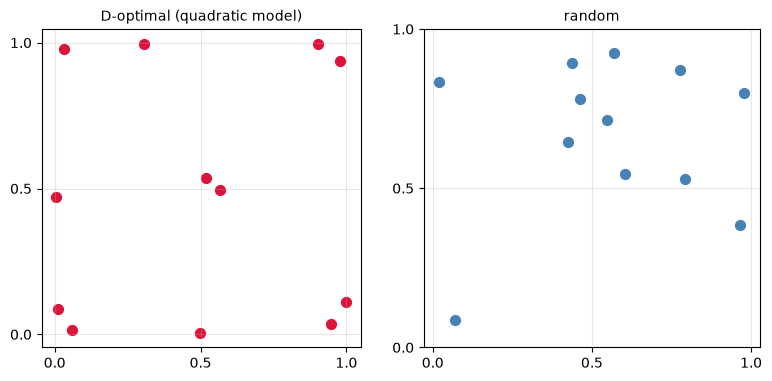

In [3]:
model = polynomial_features(2)                 # quadratic model matrix builder (the ModelMatrix)
dopt = optimal_design(bounds, 12, model=model, criterion='D', seed=0)
rand = random_design(bounds, 12, seed=0)
logdetM = lambda X: np.linalg.slogdet(model(X).T @ model(X))[1]
print('D-criterion  log|FᵀF|   D-optimal: %.2f   random: %.2f  (higher = more information)'
      % (logdetM(dopt), logdetM(rand)))

fig, ax = plt.subplots(1, 2, figsize=(8, 3.8))
for a, d, t in zip(ax, [dopt, rand], ['D-optimal (quadratic model)', 'random']):
    a.scatter(d[:, 0], d[:, 1], s=50, color='crimson' if 'opt' in t else 'steelblue')
    a.set_title(t, fontsize=10); a.set_aspect('equal'); a.set_xticks([0, 0.5, 1]); a.set_yticks([0, 0.5, 1]); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Report design efficiency

When a model is in view, judge a design by its efficiency relative to the optimal one. The D-efficiency of a design relative to the D-optimal design is $(\,|F^\top F|_{\text{design}} / |F^\top F|_{\text{opt}}\,)^{1/p}$ for $p$ model parameters - how many fewer runs the optimal design needs for the same coefficient precision. We compute the D-efficiency of a Latin hypercube for a quadratic model.


In [4]:
model = polynomial_features(2)
dopt = optimal_design(bounds, 12, model=model, criterion='D', seed=0)
lhs = latin_hypercube(bounds, 12, seed=0)
logdet = lambda X: np.linalg.slogdet(model(X).T @ model(X))[1]
p = model(dopt).shape[1]
d_eff = np.exp((logdet(lhs) - logdet(dopt)) / p)
print('model parameters p = %d' % p)
print('D-efficiency of the Latin hypercube vs the D-optimal design: %.2f' % d_eff)
print('(an LHS this much below 1.0 needs ~%.0f%% more runs for the same coefficient precision)' % (100 * (1 / d_eff - 1)))

model parameters p = 6
D-efficiency of the Latin hypercube vs the D-optimal design: 0.40
(an LHS this much below 1.0 needs ~150% more runs for the same coefficient precision)


## References

- Fisher, R. A. (1935). The Design of Experiments. Oliver & Boyd. - the founding text.
- Montgomery, D. C. (2017). Design and Analysis of Experiments, 9th ed. Wiley.
- McKay, M. D., Beckman, R. J. & Conover, W. J. (1979). A comparison of three methods for selecting values of input variables in the analysis of output from a computer code (https://doi.org/10.2307/1268522). Technometrics 21(2), 239-245. - Latin hypercube sampling.
- Atkinson, A. C., Donev, A. N. & Tobias, R. D. (2007). Optimum Experimental Designs, with SAS. Oxford University Press. - D/A/I-optimality and the Fedorov exchange.
- Santner, T. J., Williams, B. J. & Notz, W. I. (2018). The Design and Analysis of Computer Experiments, 2nd ed. Springer.


## Exercises and extensions

1. Discrepancy and the curse of dimension. Implement the centered $L_2$-discrepancy and the maximin criterion, and compare random / LHS / maximin-LHS / Sobol / Halton designs as the dimension grows from 2 to 20 at fixed $n$. Reproduce the result that low-discrepancy sequences (Sobol) retain even coverage where random sampling's coverage collapses (Santner et al.).
2. Optimal-design criteria, compared. Build D-, A-, and I-optimal designs (Atkinson et al.) for a quadratic model over a 2-D region; visualize the differing point patterns and verify each minimizes what it claims (coefficient-covariance determinant, trace, average prediction variance). Compute the D-efficiency of an LHS relative to the D-optimal design.
3. A custom criterion. Register your own optimality criterion (e.g. a Bayesian D-optimality that adds a prior information term) via `register_criterion`, and show `optimal_design` produces a sensible design under it.
4. Sequential vs one-shot designs. Compare a one-shot space-filling design + global GP fit against the sequential Bayesian optimization of bayesian_optimization for learning a surrogate (not just optimizing); quantify the prediction-error advantage of adaptivity.
